1.Problem: Implement a Python function to calculate the mean squared error (MSE)
between two lists of predicted and actual values.

In [3]:
def mean_squared_error(actual,predicted):
    if len(actual) !=len(predicted):
        raise ValueError("The list must have same lenght")

    squared_error_sum=0
                         
    for a,p in zip(actual,predicted):
        squared_error_sum += (a-p)**2

    mse=squared_error_sum/len(actual)
    return mse

actual=[2,-0.5,5,2]
predicted=[1,0.0,4,3]
mse=mean_squared_error(actual,predicted)
print(f"mean squre error:{mse}")

mean squre error:0.8125


2.Problem: Write a function to generate synthetic data using the Gaussian mixture model
(GMM) algorithm from scratch. The function should return clusters of data points.


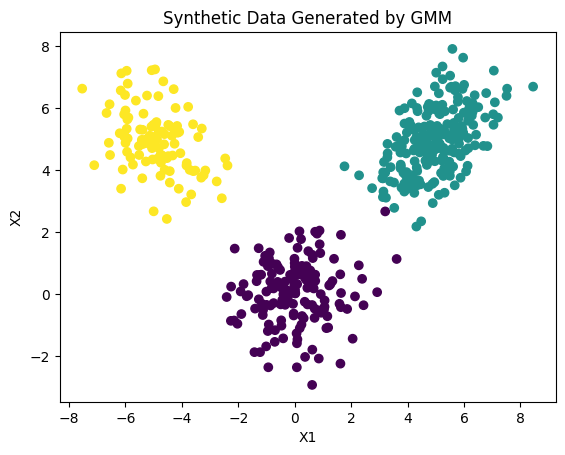

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def generate_gmm_data(n_samples, n_clusters, means, covariances, weights):
    X = np.zeros((n_samples, 2))
    labels = np.zeros(n_samples, dtype=int)
    samples_per_cluster = np.random.multinomial(n_samples, weights)
    
    start = 0
    for i in range(n_clusters):
        cluster_data = np.random.multivariate_normal(means[i], covariances[i], samples_per_cluster[i])
        X[start:start + samples_per_cluster[i], :] = cluster_data
        labels[start:start + samples_per_cluster[i]] = i
        start += samples_per_cluster[i]
    
    return X, labels

n_samples = 500
n_clusters = 3
means = [[0, 0], [5, 5], [-5, 5]]
covariances = [ [[1, 0], [0, 1]], [[1, 0.5], [0.5, 1]], [[1, -0.3], [-0.3, 1]] ]
weights = [0.3, 0.5, 0.2]

X, labels = generate_gmm_data(n_samples, n_clusters, means, covariances, weights)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Synthetic Data Generated by GMM')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


3.Problem: Implement a Python function to apply batch normalization to a layer's activations
in a neural network.


In [8]:
import numpy as np
def batch_norm(X,gamma,beta,epsilon=1e-5):
    batch_mean=np.mean(X,axis=0)
    batch_var=np.var(X,axis=0)

    x_norm=(X-batch_mean)/np.sqrt(batch_var+epsilon)
    x_out=gamma*x_norm+beta
    return x_out

X=np.array([[1,2,3,4],[2,3,4,5],[5,6,7,8]])
gamma=np.ones(X.shape[1])
beta=np.zeros(X.shape[1])
Norm_output=(X,gamma,beta)
print(Norm_output)

(array([[1, 2, 3, 4],
       [2, 3, 4, 5],
       [5, 6, 7, 8]]), array([1., 1., 1., 1.]), array([0., 0., 0., 0.]))


4.Problem: Write a function to calculate the Jaccard similarity between two sets, often used
in text mining and natural language processing tasks.

In [10]:
def jaccard_similarity(set1,set2):
    intersection=len(set1.intersection(set2))
    union=len(set1.union(set2))
    similarity=intersection/union
    return similarity

set1={"Dharani","Siri","Anju"}
set2={"Siri","hema","Anju","malathi"}
similarity=jaccard_similarity(set1,set2)
print(similarity)

0.4


5.Problem: Implement the stochastic gradient descent (SGD) algorithm for training a logistic
regression model.

In [17]:
import numpy as numpy
def sigmoid(z):
    return 1/(1+np.exp(-z))
def sgd_linear_reg(X,y,lr=0.01,epochs=100):
    n_samples,n_features=X.shape
    weights=np.zeros(n_features)
    bias=0

    for epoch in range(epochs):
        for i in range(n_samples):
            lenear_model=np.dot(X[i],weights)+bias
            y_predicted=sigmoid(lenear_model)
            dw=(y_predicted-y[i])*X[i]
            db=(y_predicted-y[i])

            weights-=lr*dw
            bias-=lr*db
    return weights,bias        

X=np.array([[1,2],[2,3],[3,4],[4,5]])
y=np.array([0,0,1,1])
lr=0.01
epochs=1000

weights,bias=sgd_linear_reg(X,y,lr,epochs)
print(weights)
print(bias)

[ 2.32668204 -0.69940598]
-3.0260880256176055


6.Problem: Write a Python function to perform the backpropagation step for a simple
feedforward neural network with one hidden layer.


In [18]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def backpropagation(X, y, weights_input_hidden, weights_hidden_output, learning_rate):
    hidden_layer_input = np.dot(X, weights_input_hidden)
    hidden_layer_output = sigmoid(hidden_layer_input)
    
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output)
    predicted_output = sigmoid(output_layer_input)

    loss = y - predicted_output

    d_predicted_output = loss * sigmoid_derivative(predicted_output)
    
    loss_hidden_layer = d_predicted_output.dot(weights_hidden_output.T)
    d_hidden_layer = loss_hidden_layer * sigmoid_derivative(hidden_layer_output)

    weights_hidden_output += hidden_layer_output.T.dot(d_predicted_output) * learning_rate
    weights_input_hidden += X.T.dot(d_hidden_layer) * learning_rate

    return weights_input_hidden, weights_hidden_output, loss

np.random.seed(0)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

weights_input_hidden = np.random.rand(2, 2)
weights_hidden_output = np.random.rand(2, 1)

learning_rate = 0.1

weights_input_hidden, weights_hidden_output, loss = backpropagation(X, y, weights_input_hidden, weights_hidden_output, learning_rate)

print("Updated Weights (Input to Hidden):")
print(weights_input_hidden)
print("Updated Weights (Hidden to Output):")
print(weights_hidden_output)
print("Loss:")
print(loss)


Updated Weights (Input to Hidden):
[[0.54839623 0.71459728]
 [0.60234939 0.54436867]]
Updated Weights (Hidden to Output):
[[0.41460817]
 [0.63674083]]
Loss:
[[-0.63059599]
 [ 0.33567673]
 [ 0.33130557]
 [-0.69531126]]


7.Problem: Implement the decision tree algorithm from scratch in Python. Given a dataset,
build a decision tree based on Gini impurity or entropy.

In [19]:
import numpy as np

class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def gini(self, y):
        classes = np.unique(y)
        gini = 1.0
        for cls in classes:
            p = len(y[y == cls]) / len(y)
            gini -= p ** 2
        return gini

    def entropy(self, y):
        classes = np.unique(y)
        entropy = 0
        for cls in classes:
            p = len(y[y == cls]) / len(y)
            if p > 0:
                entropy -= p * np.log2(p)
        return entropy

    def best_split(self, X, y):
        best_gini = float("inf")
        best_split_idx, best_split_value = None, None
        for idx in range(X.shape[1]):
            for value in np.unique(X[:, idx]):
                left_mask = X[:, idx] <= value
                right_mask = X[:, idx] > value
                gini_left = self.gini(y[left_mask])
                gini_right = self.gini(y[right_mask])
                weighted_gini = (len(y[left_mask]) * gini_left + len(y[right_mask]) * gini_right) / len(y)
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_split_idx = idx
                    best_split_value = value
        return best_split_idx, best_split_value

    def build_tree(self, X, y, depth=0):
        if len(np.unique(y)) == 1 or (self.max_depth is not None and depth >= self.max_depth):
            return np.unique(y, return_counts=True)[0][0]
        split_idx, split_value = self.best_split(X, y)
        if split_idx is None:
            return np.unique(y, return_counts=True)[0][0]
        left_mask = X[:, split_idx] <= split_value
        right_mask = X[:, split_idx] > split_value
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        return (split_idx, split_value, left_subtree, right_subtree)

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict_one(self, x, tree):
        if not isinstance(tree, tuple):
            return tree
        split_idx, split_value, left_subtree, right_subtree = tree
        if x[split_idx] <= split_value:
            return self.predict_one(x, left_subtree)
        else:
            return self.predict_one(x, right_subtree)

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])

X = np.array([[2,3], [1,1], [4,5], [6,6], [7,8]])
y = np.array([0,0,1,1,1])

tree = DecisionTree(max_depth=3)
tree.fit(X, y)
predictions = tree.predict(X)

print("Predictions:", predictions)


Predictions: [0 0 1 1 1]


8. Problem: Write a Python function to compute the F1-score given the true labels and
predicted labels for a binary classification problem.

In [30]:
def f1_score(true_labels,predicted_labels):
    tp=sum((true_labels==1)&(predicted_labels==1))
    fp=sum((true_labels==0)&(predicted_labels==1))
    fn=sum((true_labels==1)&(predicted_labels==0))

    precision=tp/(tp+fp) if(tp+fp) >0 else 0
    recall=tp/(tp+fn) if(tp+fn)>0 else 0

    if precision+recall ==0:
        return 0
    f1=2*(precision*recall)/(precision+recall)
    return f1

true_labels=np.array([1,0,0,1,0,1,0,0,1,1,0])
predicted_labels=np.array([1,1,0,1,0,1,1,0,0,1,1])

f1=f1_score(true_labels,predicted_labels)
print(f1)

0.6666666666666666


9. Problem: Implement support vector machine (SVM) classification from scratch, including
the hinge loss function and gradient-based optimization.


In [31]:
import numpy as np

class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        y_ = np.where(y <= 0, -1, 1)

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    dw = 2 * self.lambda_param * self.w
                    db = 0
                else:
                    dw = 2 * self.lambda_param * self.w - np.dot(x_i, y_[idx])
                    db = y_[idx]
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

X = np.array([[1, 2], [2, 3], [3, 3], [2, 1], [3, 2]])
y = np.array([1, 1, -1, -1, -1])

svm = SVM(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
svm.fit(X, y)

predictions = svm.predict(X)
print("Predictions:", predictions)


Predictions: [ 1.  1. -1. -1. -1.]


10. Problem: Write a Python function to compute the Pearson correlation coefficient between
two sets of data.

In [33]:
import numpy as np
def pearson_corre(x,y):
    x_mean=np.mean(x)
    y_mean=np.mean(y)

    numerator=np.sum((x-x_mean)*(y-y_mean))
    denominator=np.sqrt(np.sum((x-x_mean)**2)*np.sum((y-y_mean)**2))
    return numerator/denominator if denominator !=0 else 0

x=np.array([1,2,3,4,5])
y=np.array([2,3,4,5,6])

corre=pearson_corre(x,y)
print(corre)

1.0


11. Problem: Implement the Adagrad optimizer from scratch in Python, and use it to optimize
the parameters of a simple linear regression model.


In [34]:
import numpy as np

class LinearRegressionAdagrad:
    def __init__(self, learning_rate=0.01, epochs=1000, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.epsilon = epsilon
        self.w = None
        self.b = None
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        gradient_sum_w = np.zeros(n_features)
        gradient_sum_b = 0
        
        for _ in range(self.epochs):
            y_predicted = np.dot(X, self.w) + self.b
            dw = -(2/n_samples) * np.dot(X.T, (y - y_predicted))
            db = -(2/n_samples) * np.sum(y - y_predicted)  
            gradient_sum_w += dw**2
            gradient_sum_b += db**2
            self.w -= (self.learning_rate / (np.sqrt(gradient_sum_w) + self.epsilon)) * dw
            self.b -= (self.learning_rate / (np.sqrt(gradient_sum_b) + self.epsilon)) * db
    
    def predict(self, X):
        return np.dot(X, self.w) + self.b

X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
y = np.array([5, 7, 9, 11])

model = LinearRegressionAdagrad(learning_rate=0.1, epochs=1000)
model.fit(X, y)

predictions = model.predict(X)
print("Predictions:", predictions)


Predictions: [ 4.68487354  6.85437012  9.02386669 11.19336326]


12. Problem: Write a Python function to simulate a Markov chain. Given a transition matrix
and an initial state, return the state after a certain number of transitions.

In [39]:
import numpy as array
def markov_chain(transistion_matrix,initial_state,steps):
    n_states=len(transistion_matrix)
    current_state=initial_state

    for _ in range(steps):
        current_state=np.random.choice(n_states,p=transistion_matrix[current_state])
    return current_state

transistion_matrix=np.array([[0.7, 0.3],
                              [0.4, 0.6]])
initial_state=0
steps=10
final_state=markov_chain(transistion_matrix,initial_state,steps)
print(final_state)

0


13. Problem: Implement the Naive Bayes classifier from scratch for a binary classification
problem using Gaussian distributions for continuous features.


In [40]:
import numpy as np

class NaiveBayes:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        self.means = np.zeros((n_classes, n_features))
        self.variances = np.zeros((n_classes, n_features))
        self.priors = np.zeros(n_classes)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.means[idx, :] = X_c.mean(axis=0)
            self.variances[idx, :] = X_c.var(axis=0)
            self.priors[idx] = X_c.shape[0] / float(n_samples)

    def _gaussian_density(self, class_idx, x):
        mean = self.means[class_idx]
        var = self.variances[class_idx]
        numerator = np.exp(- (x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        for idx, c in enumerate(self.classes):
            prior = np.log(self.priors[idx])
            conditional = np.sum(np.log(self._gaussian_density(idx, x)))
            posterior = prior + conditional
            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors)]

X = np.array([[1,2], [2,3], [3,4], [4,5], [5,6]])
y = np.array([0,0,1,1,1])

nb = NaiveBayes()
nb.fit(X, y)
predictions = nb.predict(X)
print("Predictions:", predictions)


Predictions: [0 0 1 1 1]


14. Problem: Write a Python function to compute the Silhouette score for clustering results,
which is used to evaluate the quality of clusters.


In [42]:
import numpy as np
from sklearn.metrics import pairwise_distances

def silhouette_score(X, labels):
    n_samples = len(X)
    silhouette_scores = np.zeros(n_samples)
    distance_matrix = pairwise_distances(X)

    for i in range(n_samples):
        same_cluster = labels == labels[i]
        other_clusters = ~same_cluster
        a_i = np.mean(distance_matrix[i][same_cluster & (np.arange(n_samples) != i)])
        b_i = np.min([np.mean(distance_matrix[i][labels == label]) for label in np.unique(labels) if label != labels[i]])
        silhouette_scores[i] = (b_i - a_i) / max(a_i, b_i)
    
    return np.mean(silhouette_scores)

X = np.array([[1, 2], [2, 3], [3, 4], [8, 8], [9, 9]])
labels = np.array([0, 0, 0, 1, 1])

score = silhouette_score(X, labels)
print("Silhouette Score:", score)


Silhouette Score: 0.7974475544154174


15. Problem: Implement an autoencoder neural network from scratch using Python. The
network should compress and reconstruct input data.

In [43]:
import numpy as np

class Autoencoder:
    def __init__(self, input_size, hidden_size, learning_rate=0.01, epochs=1000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.W1 = np.random.rand(input_size, hidden_size)
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.rand(hidden_size, input_size)
        self.b2 = np.zeros(input_size)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def fit(self, X):
        for _ in range(self.epochs):
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            error = X - output
            
            output_gradient = error * self.sigmoid_derivative(output)
            hidden_error = output_gradient.dot(self.W2.T)
            hidden_gradient = hidden_error * self.sigmoid_derivative(hidden)

            self.W2 += hidden.T.dot(output_gradient) * self.learning_rate
            self.b2 += np.sum(output_gradient, axis=0) * self.learning_rate
            self.W1 += X.T.dot(hidden_gradient) * self.learning_rate
            self.b1 += np.sum(hidden_gradient, axis=0) * self.learning_rate

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return output

X = np.array([[0, 0, 1],
              [1, 0, 0],
              [0, 1, 0],
              [1, 1, 1]])

autoencoder = Autoencoder(input_size=3, hidden_size=2, learning_rate=0.01, epochs=10000)
autoencoder.fit(X)

reconstructed = autoencoder.predict(X)
print("Original Input:\n", X)
print("Reconstructed Output:\n", reconstructed)


Original Input:
 [[0 0 1]
 [1 0 0]
 [0 1 0]
 [1 1 1]]
Reconstructed Output:
 [[0.41981276 0.11542911 0.54830833]
 [0.56070604 0.22581575 0.60670692]
 [0.19587035 0.8912347  0.15003889]
 [0.87453266 0.81757543 0.74383503]]


16. Problem: Write a Python function to perform sentiment analysis on text data by
implementing a simple bag-of-words model combined with logistic regression.


In [44]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

def train_sentiment_analysis_model(texts, labels):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(texts).toarray()
    model = LogisticRegression()
    model.fit(X, labels)
    return model, vectorizer

def predict_sentiment(model, vectorizer, new_texts):
    X_new = vectorizer.transform(new_texts).toarray()
    predictions = model.predict(X_new)
    return predictions

texts = [
    "I love this product, it works great!",
    "Terrible service, I'm very disappointed.",
    "Fantastic experience, will buy again!",
    "Not what I expected, quite bad."
]

labels = np.array([1, 0, 1, 0])

model, vectorizer = train_sentiment_analysis_model(texts, labels)

new_texts = [
    "Absolutely love it!",
    "Horrible experience, never coming back."
]

predictions = predict_sentiment(model, vectorizer, new_texts)
print("Predictions:", predictions)


Predictions: [1 1]


17. Problem: Implement a Python function to calculate the Matthews correlation coefficient
(MCC) for evaluating binary classifiers.


In [45]:
import numpy as np

def matthews_correlation_coefficient(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    numerator = (tp * tn) - (fp * fn)
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    
    if denominator == 0:
        return 0
    return numerator / denominator

y_true = np.array([1, 0, 1, 1, 0, 1, 0])
y_pred = np.array([1, 0, 0, 1, 0, 1, 1])

mcc = matthews_correlation_coefficient(y_true, y_pred)
print("Matthews Correlation Coefficient:", mcc)


Matthews Correlation Coefficient: 0.4166666666666667


18. Problem: Write a Python function to perform the hierarchical clustering algorithm on a
dataset, and return a dendrogram representing the clusters.

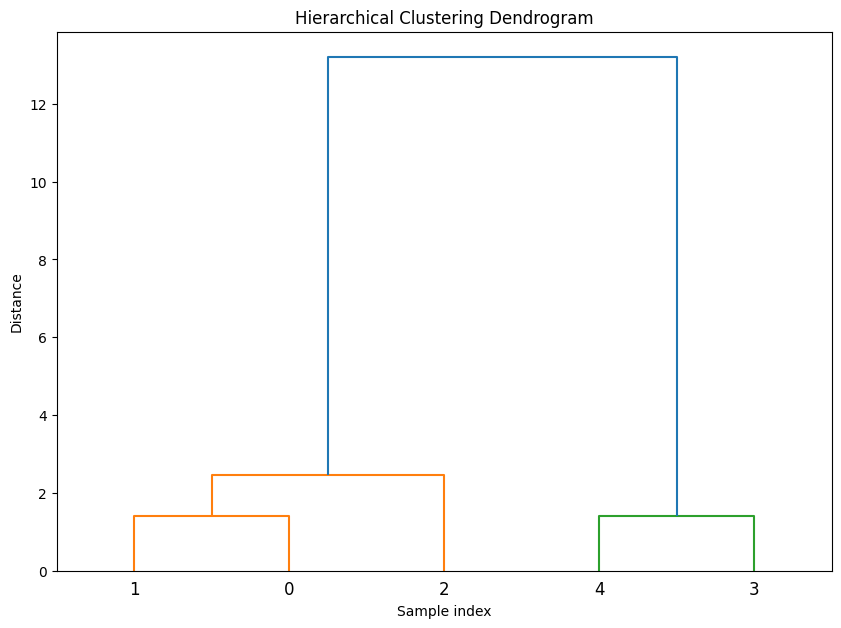

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

def hierarchical_clustering(data):
    linked = linkage(data, method='ward')
    plt.figure(figsize=(10, 7))
    dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Sample index')
    plt.ylabel('Distance')
    plt.show()

data = np.array([[1, 2], [2, 3], [3, 4], [8, 8], [9, 9]])
hierarchical_clustering(data)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

def create_gan(latent_dim):
    generator = keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=latent_dim),
        layers.Dense(784, activation='sigmoid'),
        layers.Reshape((28, 28))
    ])

    discriminator = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    discriminator.trainable = False
    gan_input = layers.Input(shape=(latent_dim,))
    generated_image = generator(gan_input)
    gan_output = discriminator(generated_image)
    gan = keras.Model(gan_input, gan_output)
    gan.compile(optimizer='adam', loss='binary_crossentropy')

    return generator, discriminator, gan

def train_gan(generator, discriminator, gan, epochs, batch_size, latent_dim):
    for epoch in range(epochs):
        noise = np.random.normal(0, 1, size=[batch_size, latent_dim])
        generated_images = generator.predict(noise)
        real_images = np.random.rand(batch_size, 28, 28)

        X = np.concatenate([real_images, generated_images])
        y_dis = np.zeros(2 * batch_size)
        y_dis[:batch_size] = 1
        
        discriminator.trainable = True
        d_loss = discriminator.train_on_batch(X, y_dis)

        noise = np.random.normal(0, 1, size=[batch_size, latent_dim])
        y_gen = np.ones(batch_size)
        discriminator.trainable = False
        g_loss = gan.train_on_batch(noise, y_gen)

        if epoch % 1000 == 0:
            print(f'Epoch: {epoch}, D Loss: {d_loss[0]}, G Loss: {g_loss[0]}')
            plot_generated_images(generator, epoch)

def plot_generated_images(generator, epoch):
    noise = np.random.normal(0, 1, size=(16, 100))
    generated_images = generator.predict(noise)
    plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'gan_epoch_{epoch}.png')
    plt.show()

latent_dim = 100
generator, discriminator, gan = create_gan(latent_dim)
train_gan(generator, discriminator, gan, epochs=10, batch_size=32, latent_dim=latent_dim)


19. Problem: Implement a function to generate synthetic images using a generative
adversarial network (GAN). The function should use random noise as input and return
generated images.

20. Problem: Write a Python function to perform time series forecasting using an ARIMA (Auto
Regressive Integrated Moving Average) model, given a sequence of historical data

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Forecasted Values: 10    10.999943
11    11.999773
12    12.999489
13    13.999091
14    14.998580
Name: predicted_mean, dtype: float64


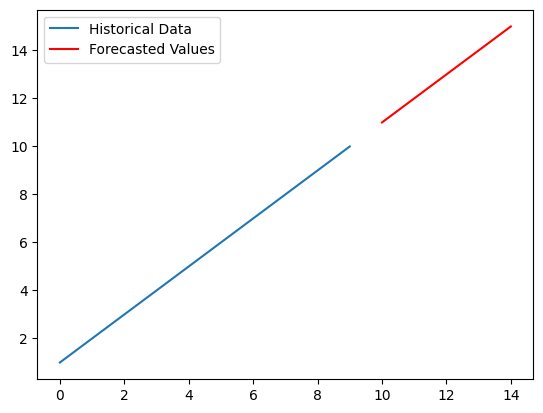

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

def forecast_time_series(data, order, steps):
    model = ARIMA(data, order=order)
    model_fit = model.fit()
    forecast = model_fit.forecast(steps)
    return forecast

data = pd.Series([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
order = (1, 1, 1)
steps = 5

forecast = forecast_time_series(data, order, steps)
print("Forecasted Values:", forecast)

plt.plot(data.index, data, label='Historical Data')
plt.plot(range(len(data), len(data) + steps), forecast, label='Forecasted Values', color='red')
plt.legend()
plt.show()
